In [12]:
import pandas as pd

result_path = "../results/20250914_195439/results_detailed.csv"
df = pd.read_csv(result_path)
df

,model,dataset,split,epoch,loss,elbo,log_prior,rmse,time
0,TPR,Bike,0,1,644.226001,-586.426167,-57.799834,1.172659,0.509901
1,TPR,Bike,0,2,572.904790,-515.271855,-57.632935,1.168050,0.017385
2,TPR,Bike,0,3,563.714777,-506.237791,-57.476986,1.170460,0.017075
3,TPR,Bike,0,4,558.796877,-501.466540,-57.330338,1.173686,0.016965
4,TPR,Bike,0,5,555.155750,-497.963089,-57.192661,1.176526,0.017058
...,...,...,...,...,...,...,...,...,...
15995,XuTPR,Neal_XOutlier,9,96,66.860739,-63.645471,-3.215268,2.788204,0.009483
15996,XuTPR,Neal_XOutlier,9,97,65.281886,-62.085870,-3.196016,2.834248,0.012154
15997,XuTPR,Neal_XOutlier,9,98,65.791329,-62.614166,-3.177163,2.830847,0.011419
15998,XuTPR,Neal_XOutlier,9,99,64.984750,-61.826188,-3.158562,2.870471,0.009526


In [13]:
import pandas as pd

# データフレーム 'df' が既に読み込まれていると仮定します
# df = pd.read_csv("...") 

# model, dataset, epoch の組み合わせでグループ化し、
# 各数値列の平均と標準偏差を計算する
summary_df = df.groupby(['model', 'dataset', 'epoch']).agg({
    'loss': ['mean', 'std'],
    'elbo': ['mean', 'std'],
    'log_prior': ['mean', 'std'],
    'rmse': ['mean', 'std']
})

# 結果を表示
print(summary_df)

# (オプション) マルチレベルのカラムをフラットにする場合
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

print("\n--- フラットにしたデータフレーム ---")
print(summary_df)

                                  loss                      elbo               \
                                  mean          std         mean          std   
model dataset       epoch                                                       
TPR   Bike          1      4671.472349  6576.787824 -4610.037868  6577.918498   
                    2       593.583137    39.256469  -532.360320    39.492800   
                    3       580.115871    38.577578  -519.091212    38.284062   
                    4       575.271506    38.344571  -514.436541    37.986844   
                    5       571.797729    37.977996  -511.145486    37.591084   
...                                ...          ...          ...          ...   
XuTPR Neal_XOutlier 96       62.920600    14.684276   -60.573344    14.502512   
                    97       61.903255    13.936943   -59.573712    13.715990   
                    98       61.721336    14.166658   -59.409350    13.943072   
                    99      

In [15]:
summary_df.columns.values

array(['model', 'dataset', 'epoch', 'loss_mean', 'loss_std', 'elbo_mean',
       'elbo_std', 'log_prior_mean', 'log_prior_std', 'rmse_mean',
       'rmse_std'], dtype=object)

--- 修正後の正しいデータフレームの先頭 ---
   index model dataset  epoch    loss_mean     loss_std    elbo_mean  \
0      0   TPR    Bike      1  4671.472349  6576.787824 -4610.037868   
1      1   TPR    Bike      2   593.583137    39.256469  -532.360320   
2      2   TPR    Bike      3   580.115871    38.577578  -519.091212   
3      3   TPR    Bike      4   575.271506    38.344571  -514.436541   
4      4   TPR    Bike      5   571.797729    37.977996  -511.145486   

      elbo_std  log_prior_mean  log_prior_std  rmse_mean  rmse_std  \
0  6577.918498      -61.434481       3.093484   0.985030  0.142347   
1    39.492800      -61.222817       3.060028   0.969993  0.139045   
2    38.284062      -61.024659       3.029286   0.972494  0.138449   
3    37.986844      -60.834964       3.000226   0.975725  0.138231   
4    37.591084      -60.652243       2.971704   0.978467  0.138181   

   negative_elbo_mean  negative_elbo_std  
0         4610.037868        6577.918498  
1          532.360320          39.


'Bike'のグラフを performance_plot_final_Bike.png として保存しました。

'Concrete'のグラフを performance_plot_final_Concrete.png として保存しました。

'Diabetes'のグラフを performance_plot_final_Diabetes.png として保存しました。

'ELE'のグラフを performance_plot_final_ELE.png として保存しました。

'MPG'のグラフを performance_plot_final_MPG.png として保存しました。

'Machine_CPU'のグラフを performance_plot_final_Machine_CPU.png として保存しました。

'Neal'のグラフを performance_plot_final_Neal.png として保存しました。

'Neal_XOutlier'のグラフを performance_plot_final_Neal_XOutlier.png として保存しました。


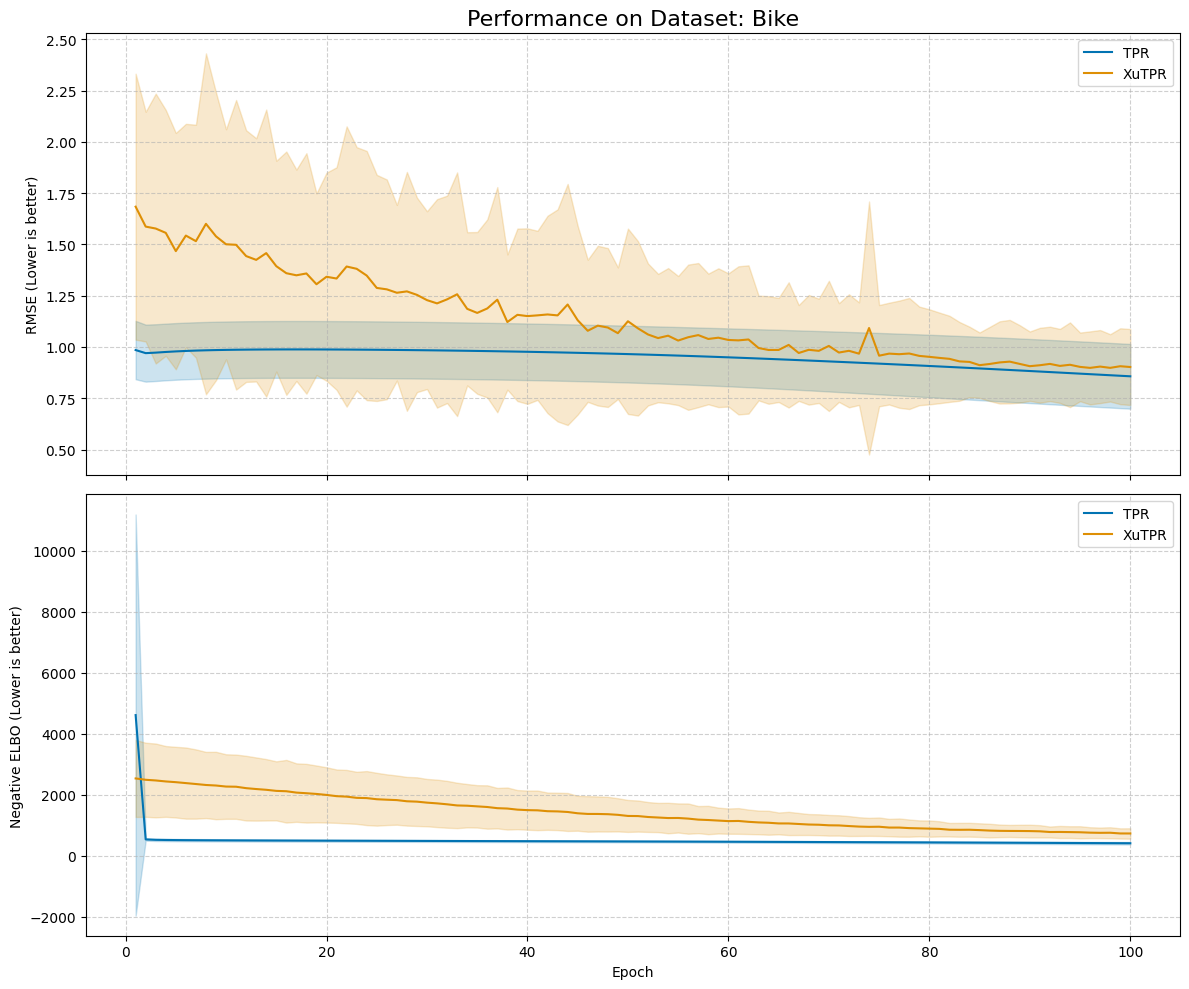

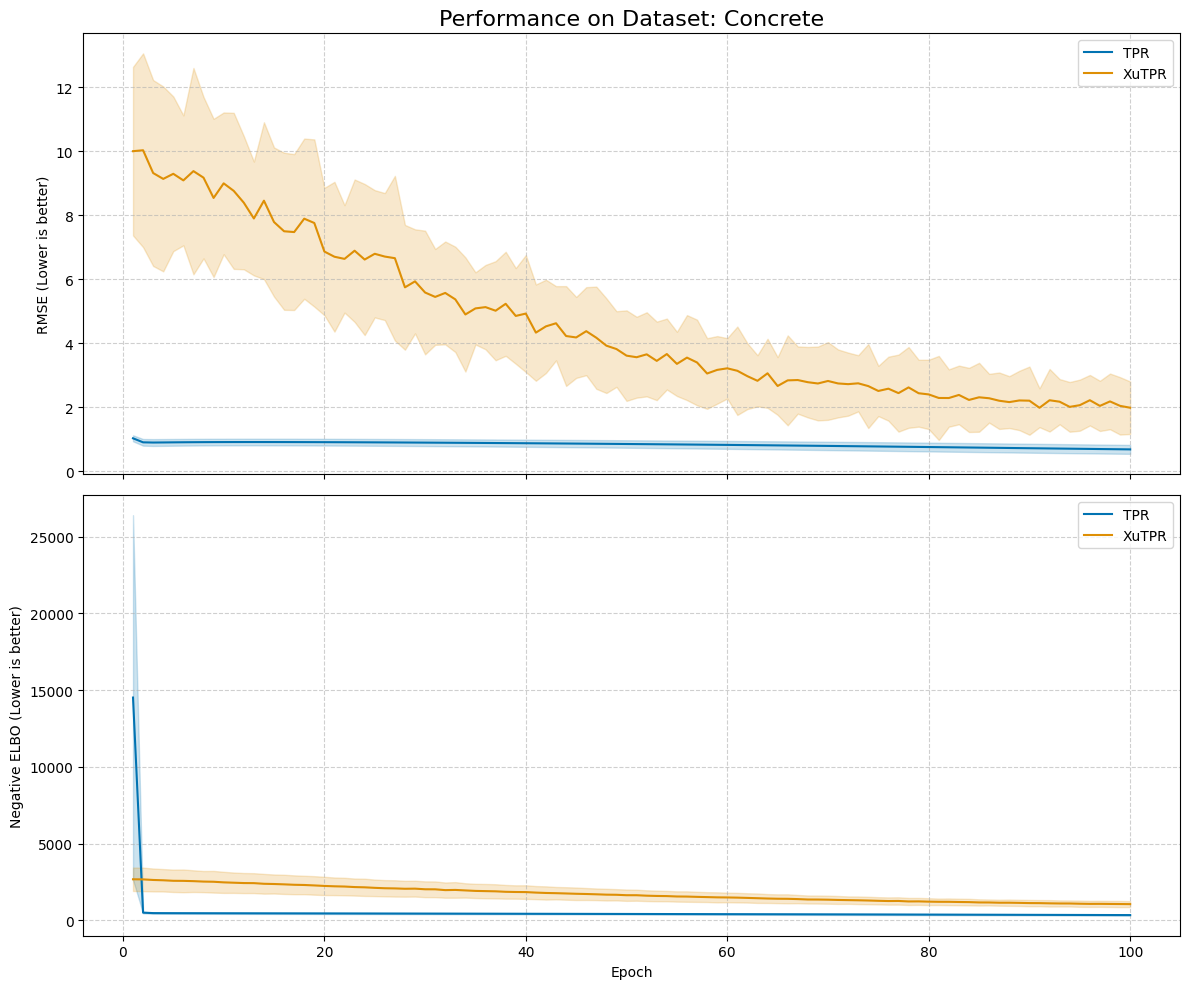

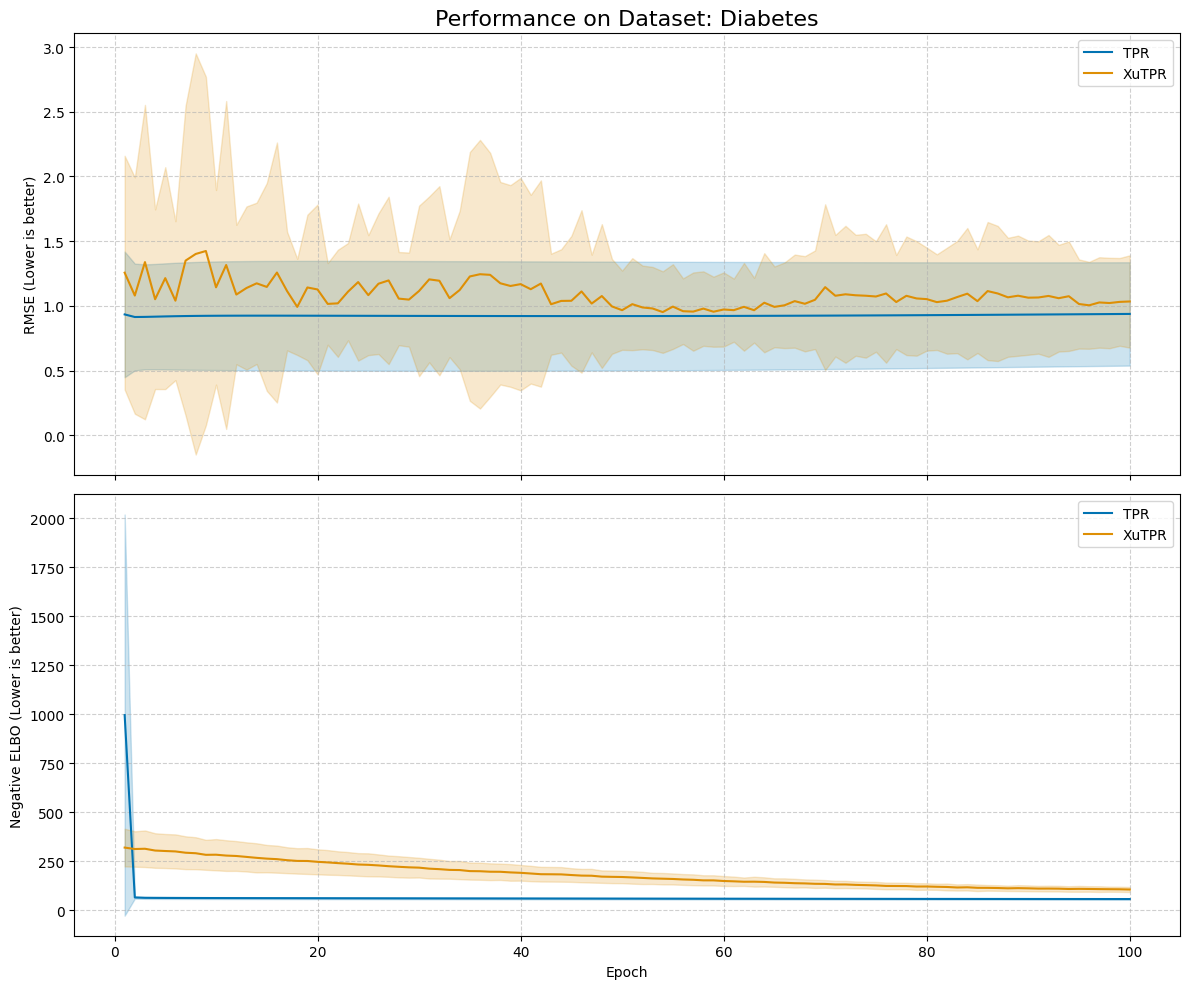

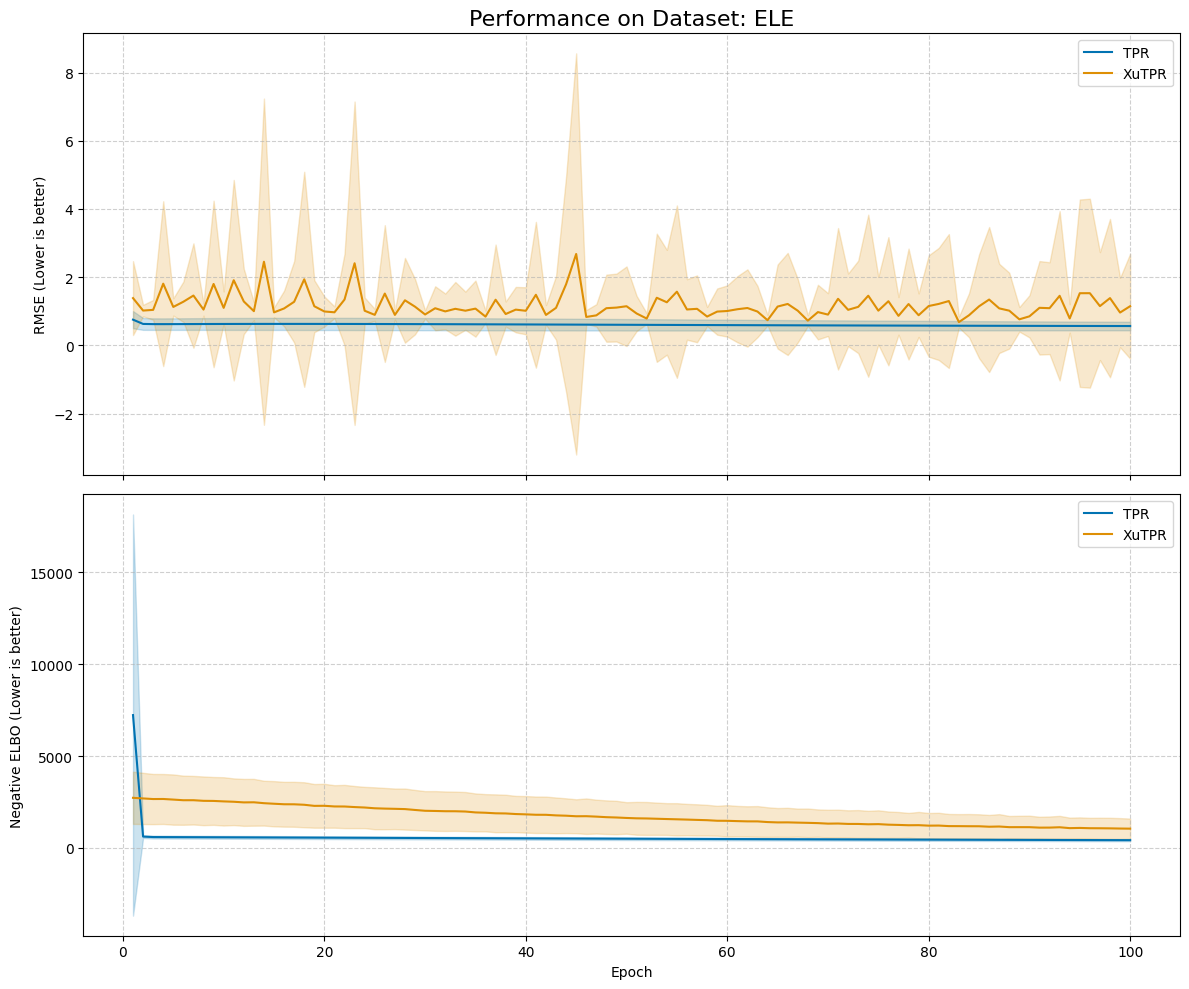

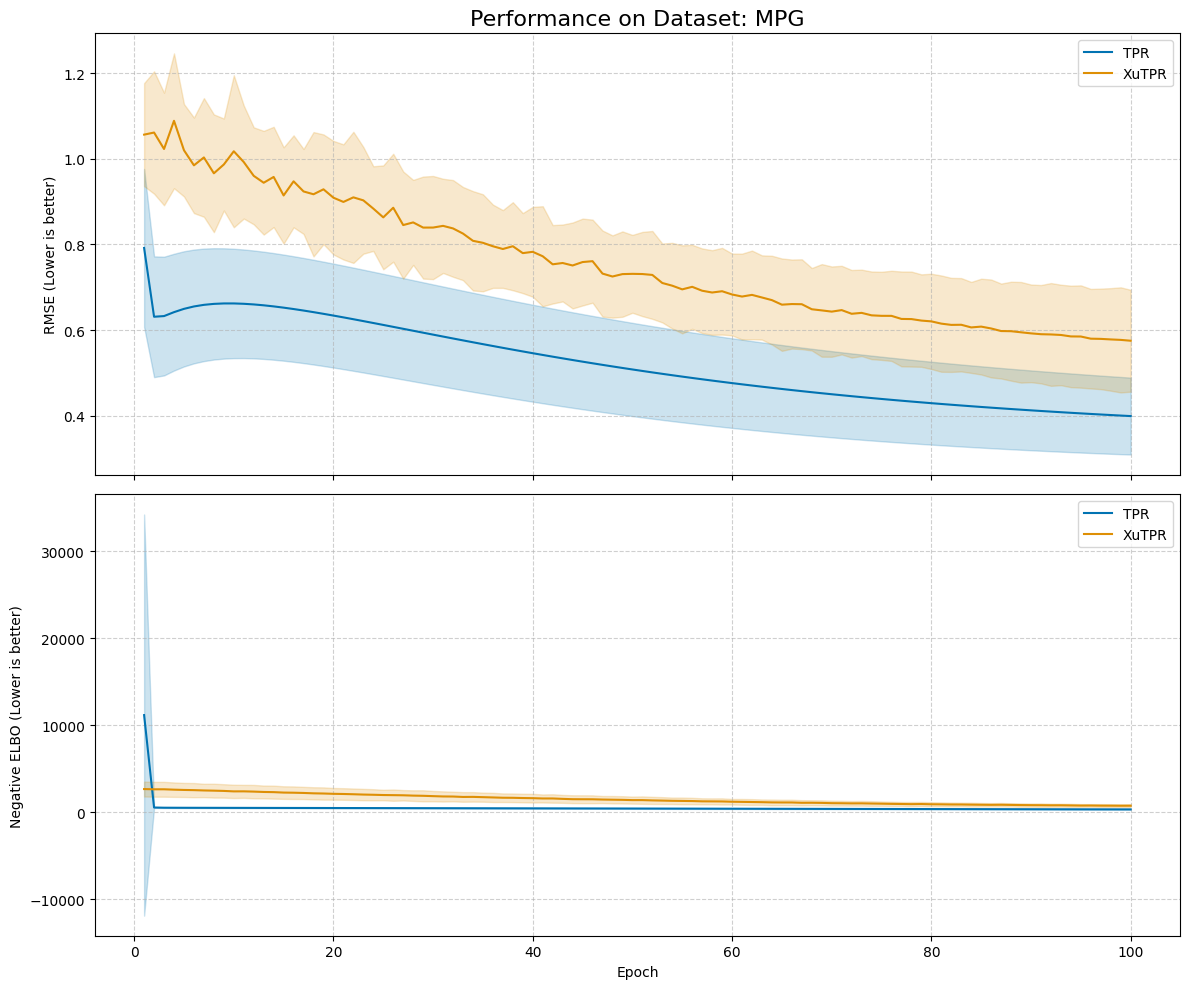

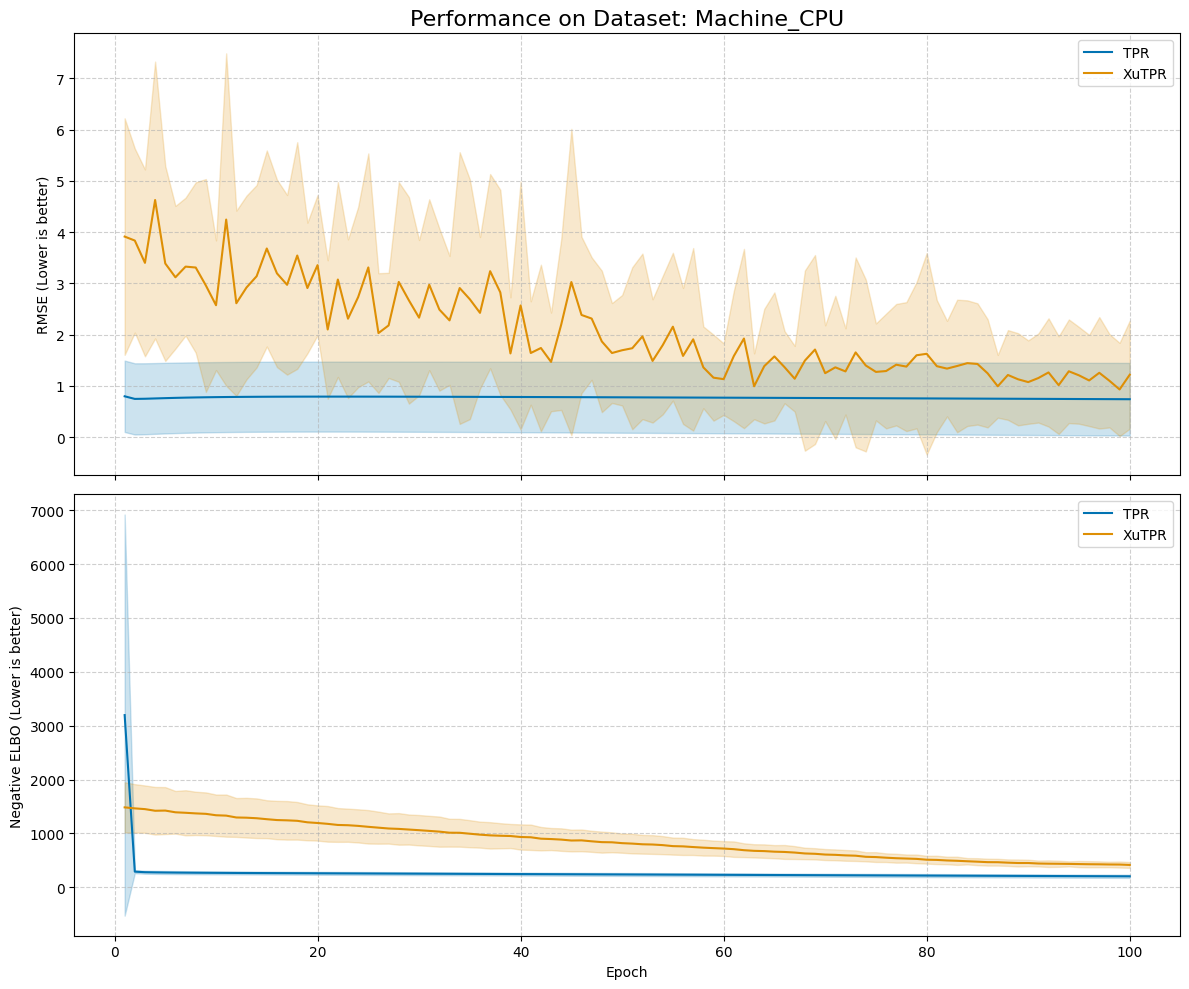

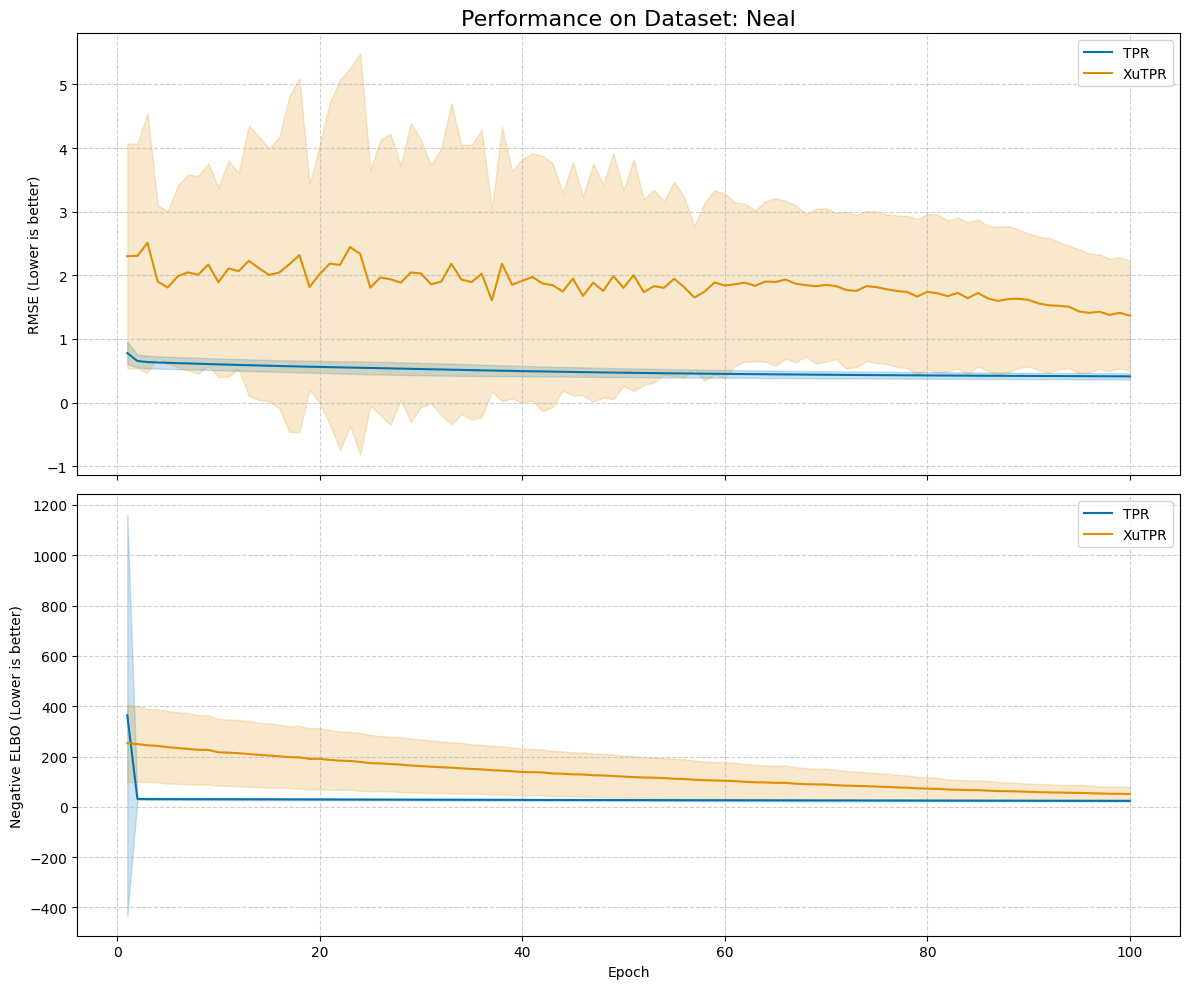

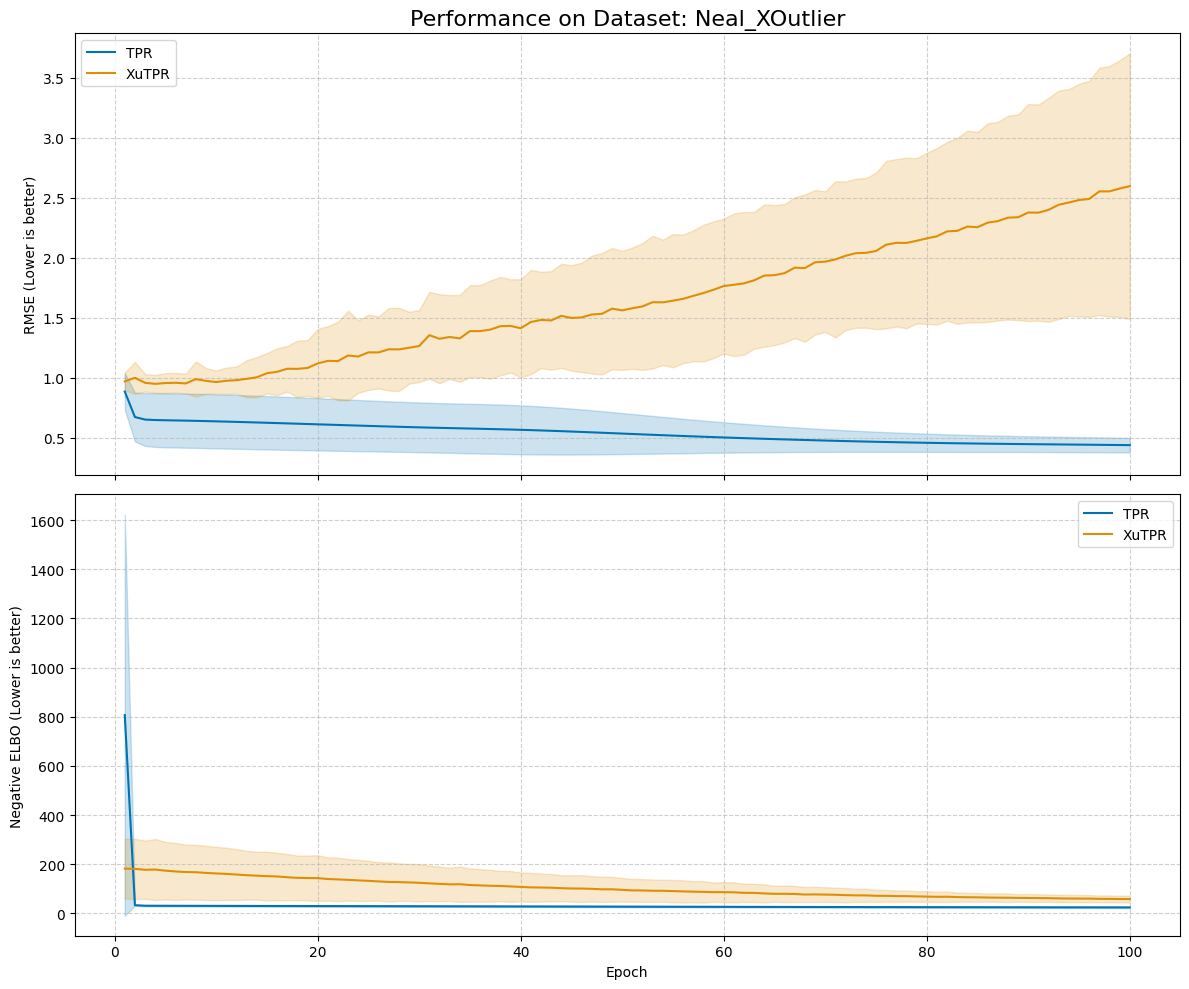

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # ダミーデータ用

import pandas as pd

result_path = "../results/20250914_195439/results_detailed.csv"
df = pd.read_csv(result_path)


summary_df = df.groupby(['model', 'dataset', 'epoch']).agg({
    'loss': ['mean', 'std'],
    'elbo': ['mean', 'std'],
    'log_prior': ['mean', 'std'],
    'rmse': ['mean', 'std']
})

plot_data = summary_df.reset_index()

# 3. 'negative_elbo' の統計量を計算 (カラム名は 'elbo_mean', 'elbo_std' になっている)
plot_data['negative_elbo_mean'] = -plot_data['elbo_mean']
plot_data['negative_elbo_std'] = plot_data['elbo_std']

# これで 'plot_data' は 'model', 'dataset', 'rmse_mean' などの
# 綺麗なカラム名を持つ、理想的なデータフレームになります。
print("--- 修正後の正しいデータフレームの先頭 ---")
print(plot_data.head())
print("\n--- カラム名 ---")
print(plot_data.columns)

# -----------------------------------------------------------------------------
# ▼▼▼ 以下は、この綺麗なデータフレームを使ったプロット処理です（変更なし）▼▼▼
# -----------------------------------------------------------------------------

unique_datasets = plot_data['dataset'].unique()
palette = sns.color_palette("colorblind", n_colors=len(plot_data['model'].unique()))

for dataset_name in unique_datasets:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    subset = plot_data[plot_data['dataset'] == dataset_name]
    
    for i, model_name in enumerate(subset['model'].unique()):
        model_data = subset[subset['model'] == model_name]
        color = palette[i]
        
        # RMSE
        ax1.plot(model_data['epoch'], model_data['rmse_mean'], label=model_name, color=color)
        ax1.fill_between(model_data['epoch'], model_data['rmse_mean'] - model_data['rmse_std'], model_data['rmse_mean'] + model_data['rmse_std'], alpha=0.2, color=color)
        
        # Negative ELBO
        ax2.plot(model_data['epoch'], model_data['negative_elbo_mean'], label=model_name, color=color)
        ax2.fill_between(model_data['epoch'], model_data['negative_elbo_mean'] - model_data['negative_elbo_std'], model_data['negative_elbo_mean'] + model_data['negative_elbo_std'], alpha=0.2, color=color)

    ax1.set_title(f'Performance on Dataset: {dataset_name}', fontsize=16)
    ax1.set_ylabel('RMSE (Lower is better)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.set_ylabel('Negative ELBO (Lower is better)')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(f"performance_plot_final_{dataset_name}.png", dpi=300)
    print(f"\n'{dataset_name}'のグラフを performance_plot_final_{dataset_name}.png として保存しました。")


'Bike'のグラフを performance_plot_combined_Bike.png として保存しました。



'Concrete'のグラフを performance_plot_combined_Concrete.png として保存しました。

'Diabetes'のグラフを performance_plot_combined_Diabetes.png として保存しました。

'ELE'のグラフを performance_plot_combined_ELE.png として保存しました。

'MPG'のグラフを performance_plot_combined_MPG.png として保存しました。

'Machine_CPU'のグラフを performance_plot_combined_Machine_CPU.png として保存しました。

'Neal'のグラフを performance_plot_combined_Neal.png として保存しました。

'Neal_XOutlier'のグラフを performance_plot_combined_Neal_XOutlier.png として保存しました。


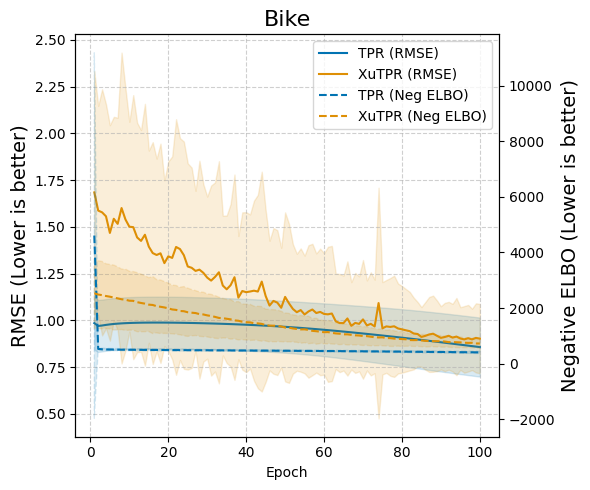

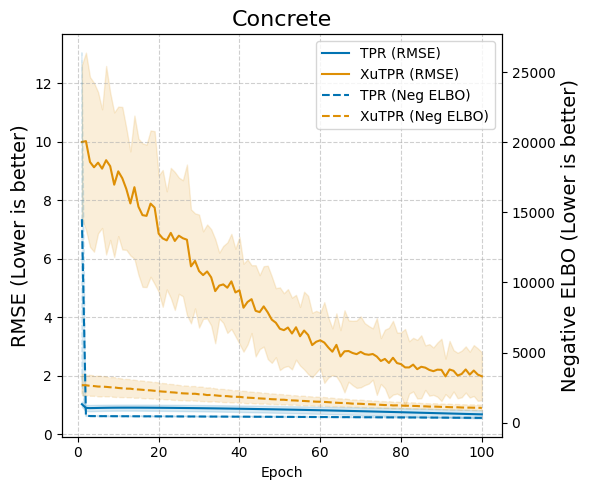

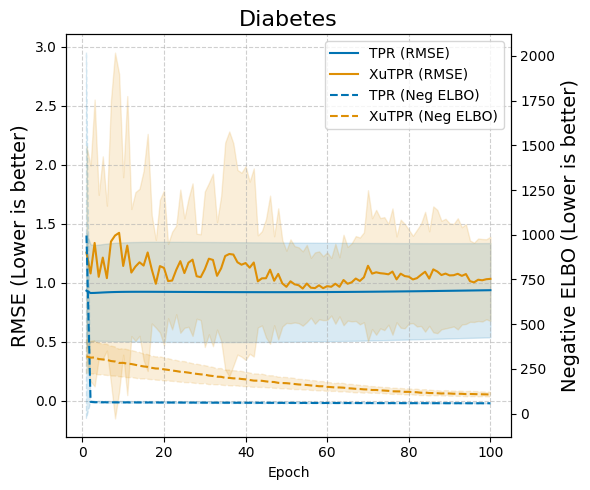

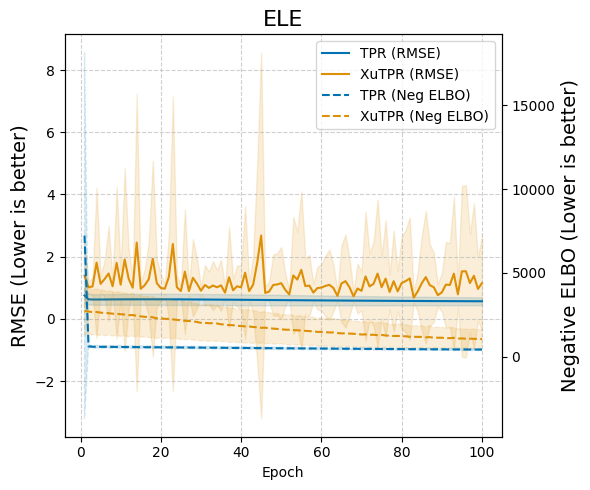

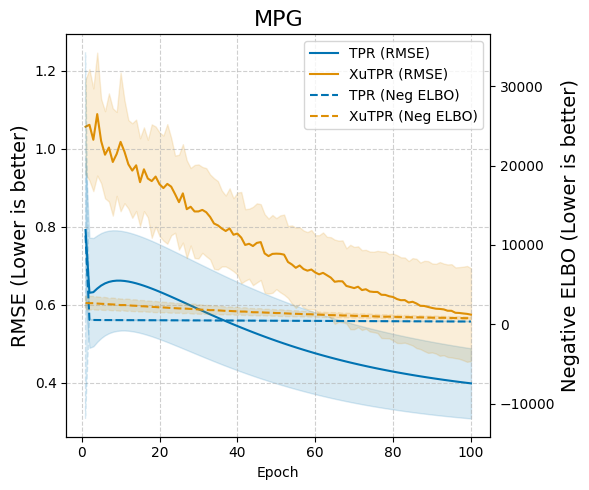

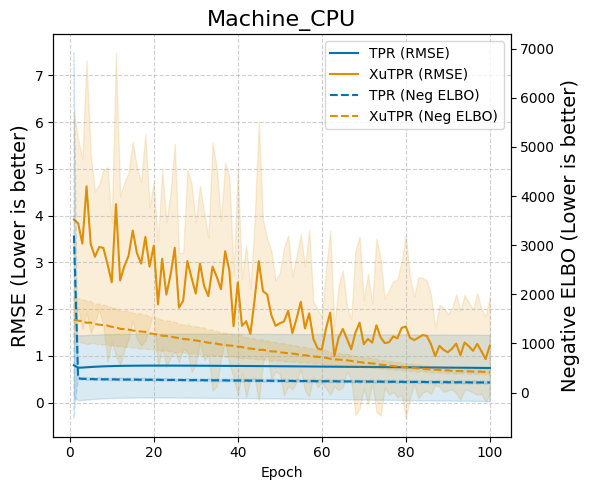

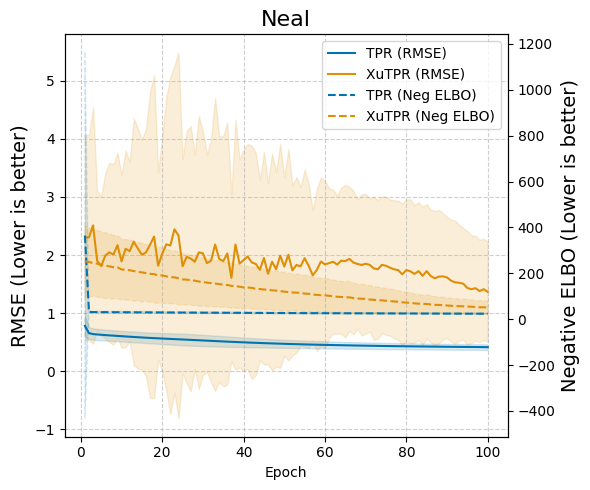

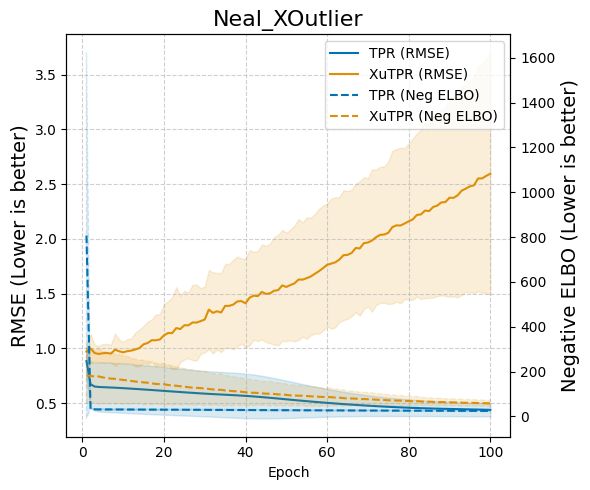

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CSVファイルからデータを読み込む
result_path = "../results/20250914_195439/results_detailed.csv"
df = pd.read_csv(result_path)

# 2. 'model', 'dataset', 'epoch' でグループ化し、統計量を計算
summary_df = df.groupby(['model', 'dataset', 'epoch']).agg({
    'loss': ['mean', 'std'],
    'elbo': ['mean', 'std'],
    'log_prior': ['mean', 'std'],
    'rmse': ['mean', 'std']
})

# 3. プロット用にデータフレームを整形
# 3a. マルチレベルのカラム名をフラット化 (例: ('rmse', 'mean') -> 'rmse_mean')
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]

# 3b. インデックスを列に戻す
plot_data = summary_df.reset_index()

# 3c. Negative ELBOの統計量を計算
plot_data['negative_elbo_mean'] = -plot_data['elbo_mean']
plot_data['negative_elbo_std'] = plot_data['elbo_std']


# 4. データセットごとにグラフを生成
unique_datasets = plot_data['dataset'].unique()
palette = sns.color_palette("colorblind", n_colors=len(plot_data['model'].unique()))

for dataset_name in unique_datasets:
    # グラフのキャンバス(ax1)を1つ作成
    fig, ax1 = plt.subplots(figsize=(6, 5))
    # ax1とX軸を共有する2つ目のY軸(ax2)を作成
    ax2 = ax1.twinx()
    
    subset = plot_data[plot_data['dataset'] == dataset_name]
    
    for i, model_name in enumerate(subset['model'].unique()):
        model_data = subset[subset['model'] == model_name]
        color = palette[i]
        
        # --- RMSEのプロット (左軸 ax1, 実線) ---
        ax1.plot(model_data['epoch'], model_data['rmse_mean'], label=f'{model_name} (RMSE)', color=color, linestyle='-')
        ax1.fill_between(
            model_data['epoch'],
            model_data['rmse_mean'] - model_data['rmse_std'],
            model_data['rmse_mean'] + model_data['rmse_std'],
            alpha=0.15,
            color=color
        )
        
        # --- Negative ELBOのプロット (右軸 ax2, 破線) ---
        ax2.plot(model_data['epoch'], model_data['negative_elbo_mean'], label=f'{model_name} (Neg ELBO)', color=color, linestyle='--')
        ax2.fill_between(
            model_data['epoch'],
            model_data['negative_elbo_mean'] - model_data['negative_elbo_std'],
            model_data['negative_elbo_mean'] + model_data['negative_elbo_std'],
            alpha=0.15,
            color=color,
            linestyle='--'
        )

    # --- グラフの体裁を整える ---
    ax1.set_title(f'{dataset_name}', fontsize=16)
    ax1.set_xlabel('Epoch')

    # Y軸のラベルと色を設定
    ax1.set_ylabel('RMSE (Lower is better)', fontsize=14)
    ax2.set_ylabel('Negative ELBO (Lower is better)', fontsize=14)
    ax1.tick_params(axis='y')
    ax2.tick_params(axis='y')
    
    # --- 凡例を結合して表示 ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.grid(True, linestyle='--', alpha=0.6)
    
    fig.tight_layout() # ラベルが重ならないように調整
    plt.savefig(f"performance_plot_combined_{dataset_name}.png", dpi=300)
    print(f"\n'{dataset_name}'のグラフを performance_plot_combined_{dataset_name}.png として保存しました。")

SyntaxError: invalid syntax (146514945.py, line 1)


'Bike'のグラフを performance_plot_combined_Bike.png として保存しました。

'Concrete'のグラフを performance_plot_combined_Concrete.png として保存しました。

'Diabetes'のグラフを performance_plot_combined_Diabetes.png として保存しました。

'ELE'のグラフを performance_plot_combined_ELE.png として保存しました。

'MPG'のグラフを performance_plot_combined_MPG.png として保存しました。

'Machine_CPU'のグラフを performance_plot_combined_Machine_CPU.png として保存しました。

'Neal'のグラフを performance_plot_combined_Neal.png として保存しました。

'Neal_XOutlier'のグラフを performance_plot_combined_Neal_XOutlier.png として保存しました。


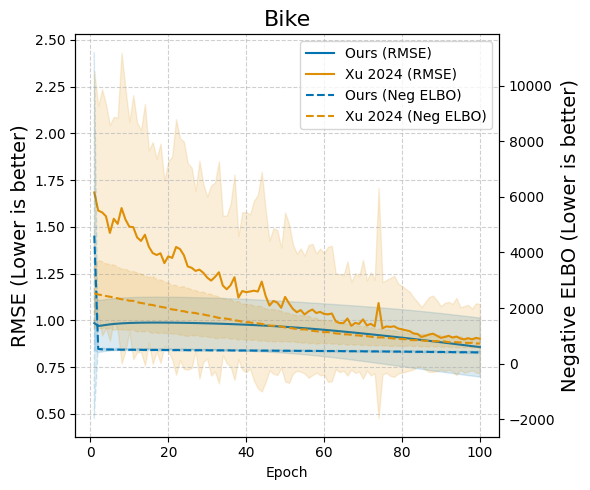

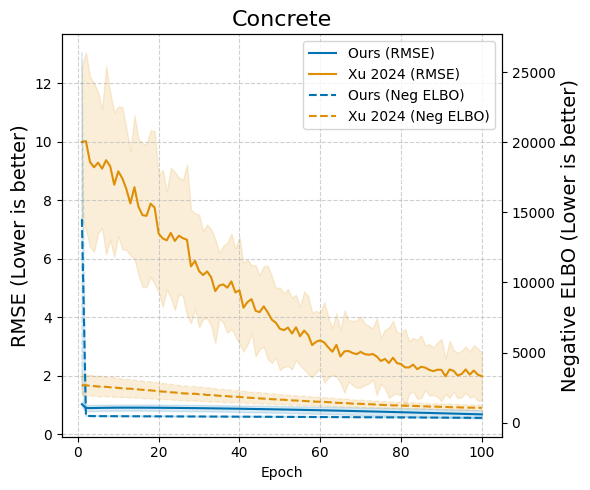

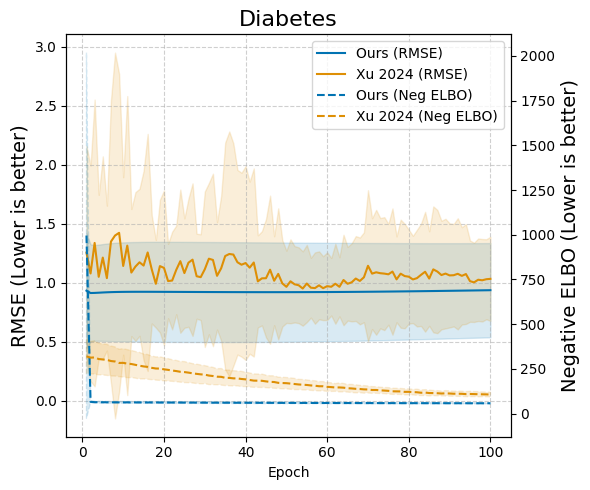

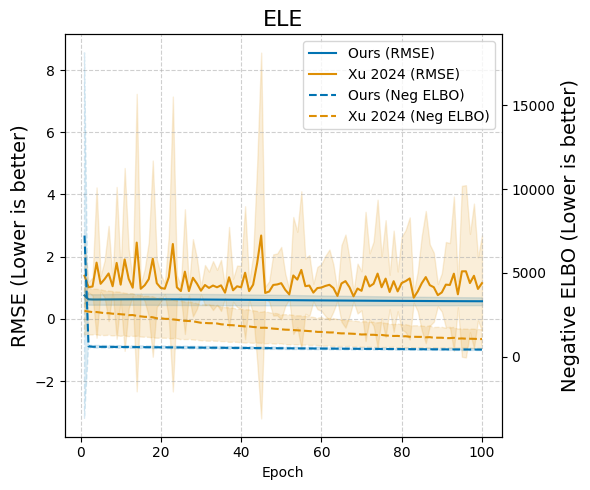

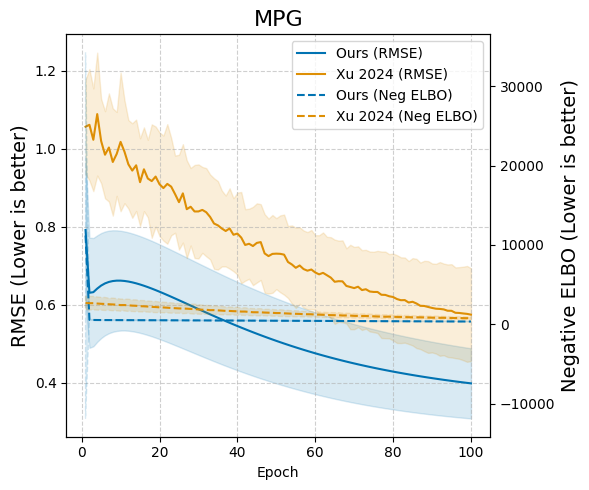

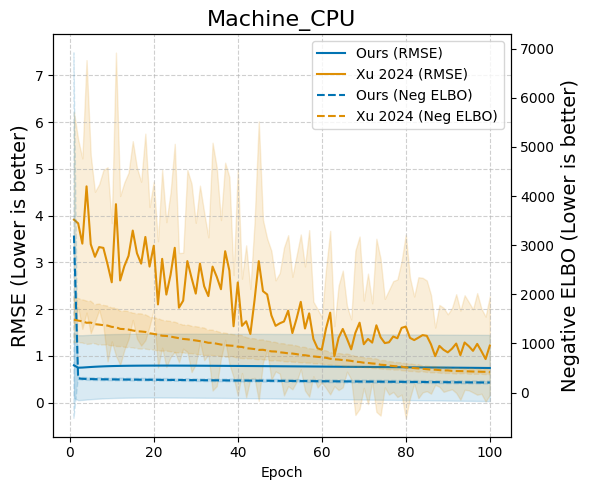

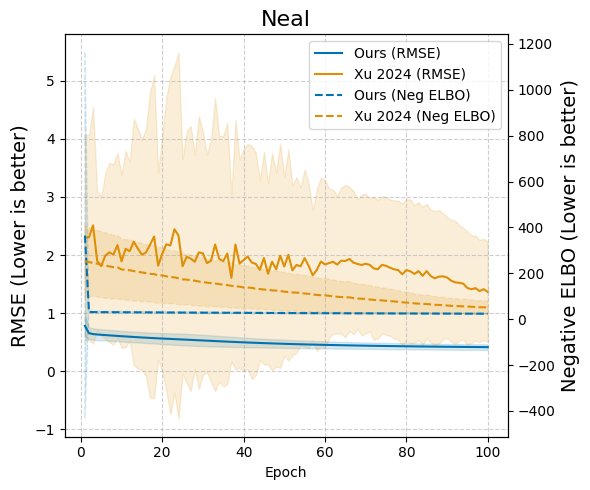

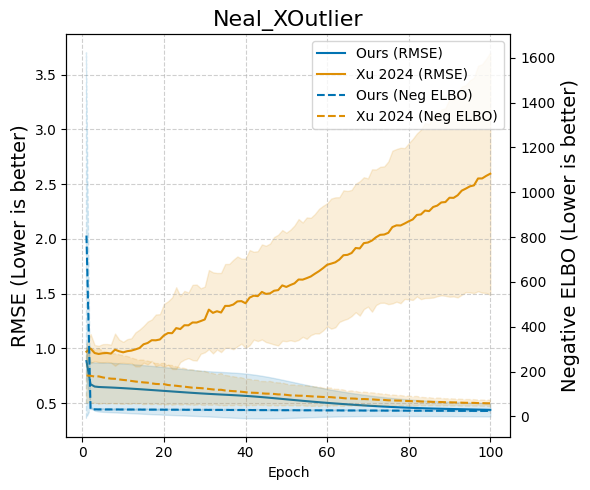

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CSVファイルからデータを読み込む
result_path = "../results/20250914_195439/results_detailed.csv"
df = pd.read_csv(result_path)

# 2. 'model', 'dataset', 'epoch' でグループ化し、統計量を計算
summary_df = df.groupby(['model', 'dataset', 'epoch']).agg({
    'loss': ['mean', 'std'],
    'elbo': ['mean', 'std'],
    'log_prior': ['mean', 'std'],
    'rmse': ['mean', 'std']
})

# 3. プロット用にデータフレームを整形
# 3a. マルチレベルのカラム名をフラット化
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]

# 3b. インデックスを列に戻す
plot_data = summary_df.reset_index()

# 3c. Negative ELBOの統計量を計算
plot_data['negative_elbo_mean'] = -plot_data['elbo_mean']
plot_data['negative_elbo_std'] = plot_data['elbo_std']


# 4. データセットごとにグラフを生成
unique_datasets = plot_data['dataset'].unique()
palette = sns.color_palette("colorblind", n_colors=len(plot_data['model'].unique()))

for dataset_name in unique_datasets:
    fig, ax1 = plt.subplots(figsize=(6, 5))
    ax2 = ax1.twinx()
    
    subset = plot_data[plot_data['dataset'] == dataset_name]
    
    # ▼▼▼【変更点】凡例用の名前マッピング辞書を定義 ▼▼▼
    legend_map = {
        'TPR': 'Ours',
        'XuTPR': 'Xu 2024'
    }
    
    for i, model_name in enumerate(subset['model'].unique()):
        model_data = subset[subset['model'] == model_name]
        color = palette[i]
        
        # ▼▼▼【変更点】辞書を使って表示名を取得 ▼▼▼
        display_name = legend_map.get(model_name, model_name) # 辞書にない場合は元の名前を使う
        
        # --- RMSEのプロット (左軸 ax1, 実線) ---
        ax1.plot(model_data['epoch'], model_data['rmse_mean'], label=f'{display_name} (RMSE)', color=color, linestyle='-')
        ax1.fill_between(
            model_data['epoch'],
            model_data['rmse_mean'] - model_data['rmse_std'],
            model_data['rmse_mean'] + model_data['rmse_std'],
            alpha=0.15,
            color=color
        )
        
        # --- Negative ELBOのプロット (右軸 ax2, 破線) ---
        ax2.plot(model_data['epoch'], model_data['negative_elbo_mean'], label=f'{display_name} (Neg ELBO)', color=color, linestyle='--')
        ax2.fill_between(
            model_data['epoch'],
            model_data['negative_elbo_mean'] - model_data['negative_elbo_std'],
            model_data['negative_elbo_mean'] + model_data['negative_elbo_std'],
            alpha=0.15,
            color=color,
            linestyle='--'
        )

    # --- グラフの体裁を整える ---
    ax1.set_title(f'{dataset_name}', fontsize=16)
    ax1.set_xlabel('Epoch')

    # Y軸のラベルと色を設定
    ax1.set_ylabel('RMSE (Lower is better)', fontsize=14)
    ax2.set_ylabel('Negative ELBO (Lower is better)', fontsize=14)
    ax1.tick_params(axis='y')
    ax2.tick_params(axis='y')
    
    # --- 凡例を結合して表示 ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.grid(True, linestyle='--', alpha=0.6)
    
    fig.tight_layout() # ラベルが重ならないように調整
    plt.savefig(f"performance_plot_combined_{dataset_name}.png", dpi=300)
    print(f"\n'{dataset_name}'のグラフを performance_plot_combined_{dataset_name}.png として保存しました。")